# Premiers pas avec Python

Ce notebook est un **kit de survie** : les concepts Python dont vous avez besoin pour le reste de la formation. Si vous savez déjà programmer en Python, survolez — vous connaissez probablement tout ça. Si Python est nouveau pour vous, ce notebook pose les bases.

> Exécutez chaque cellule avec `Shift + Enter` et observez le résultat avant de passer à la suivante.

## Commentaires

En Python, tous les caractères allant du `#` jusqu'à la fin de la ligne sont ignorés par l'interpréteur. Les commentaires servent à documenter votre code — en data science, ils sont essentiels pour expliquer *pourquoi* vous faites une transformation, pas juste *comment*.

> La cellule suivante supprime les avertissements de version (FutureWarning) pour garder l'affichage propre — c'est une convention courante en début de notebook.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Premier commentaire
print("Hello, Python!"); # Deuxième commentaire

Hello, Python!


## Sortie écran

La fonction `print()` affiche du texte dans la console. Dans un notebook Jupyter, la dernière expression d'une cellule s'affiche automatiquement — mais `print()` reste utile quand on veut afficher plusieurs valeurs.

Python propose plusieurs façons de formater du texte. La méthode moderne et recommandée est la **f-string** (préfixe `f"..."`) — elle est plus lisible que l'ancienne méthode `.format()` :

In [3]:
# Simple
print('Hello')

Hello


In [4]:
# Avec variable

nom    = "Dupont"
prenom = 'Paul'
print (f'Hello {nom} {prenom}')
print ('Hello {0} {1}'.format( nom , prenom ) )

Hello Dupont Paul
Hello Dupont Paul


In [5]:
chaineFormatee= """Ceci est une chaîne

formatée."""
print(chaineFormatee)

Ceci est une chaîne

formatée.


## Les variables

Python est **typé dynamiquement** : pas besoin de déclarer le type d'une variable, Python le déduit tout seul. C'est pratique pour le prototypage rapide, mais attention : en data science, le type de vos données (numérique, texte, booléen) détermine ce que vos algorithmes peuvent en faire.

### Les chaînes de caractères

Les chaînes (`str`) sont omniprésentes en data science : noms de colonnes, catégories textuelles, labels... Python offre des outils puissants pour les manipuler.

**Méthodes les plus utiles pour le nettoyage de données :**

```python
"  Hello World  ".strip()       # → "Hello World" (supprime les espaces)
"Hello World".lower()           # → "hello world"
"Hello World".replace("o", "0") # → "Hell0 W0rld"
"nom,prenom,age".split(",")     # → ["nom", "prenom", "age"]
"-".join(["a", "b", "c"])       # → "a-b-c"
```

Ces méthodes sont cruciales quand on nettoie des données : `.strip()` pour les espaces parasites, `.lower()` pour normaliser la casse, `.split()` pour découper des chaînes en colonnes.

In [6]:
data = 'hello world'
print(data[0])
print(len(data))
print(data)

h
11
hello world


### Les valeurs numériques

Les types numériques sont le coeur du calcul en data science. Python distingue les entiers (`int`) des nombres à virgule flottante (`float`).

**Conversion de types** (casting) — essentiel quand on charge des données depuis un CSV (tout arrive en texte) :

```python
int("42")         # → 42 (texte vers entier)
float("3.14")     # → 3.14 (texte vers décimal)
str(42)           # → "42" (nombre vers texte)
int(3.7)          # → 3 (troncature ! pas d'arrondi)
```

In [7]:
value = 123.1
print(value)
value = 10
print(value)

123.1
10


In [8]:
# Types numériques
val1 = 5 # entier (positif ou negatif)
val2 = 1.1 # float (partie décimale)
val3 = 11e-1 ; # float (notation scientifique)
val4 = complex(1, 2) # (nombre complexe de partie réelle 1 et imaginaire 2)

### Les valeurs booléennes

Python met à disposition un type `bool` avec deux valeurs : `True` et `False`. En data science, les booléens sont partout : filtrer des lignes d'un DataFrame, tester des conditions, créer des masques...

Particularité utile : `True` et `False` peuvent être convertis en valeurs numériques (1 et 0), ce qui permet de les utiliser dans des calculs (par exemple, compter le nombre de `True` avec `sum()`).

In [9]:
a = True
b = False
print(a, b)
print(a + 1)
print(b + 1)

True False
2
1


### Déclarations multiples

Python permet d'assigner plusieurs variables en une seule ligne. C'est un raccourci que vous verrez souvent.

In [10]:
a, b, c = 1, 2, 3
print(a, b, c)

1 2 3


> **Note :** Le `;` permet d'écrire plusieurs instructions sur une même ligne, mais c'est rarement utilisé en pratique. Préférez une instruction par ligne pour la lisibilité.

In [11]:
a, b, c = 1, 2, 3; print(a, b, c)

1 2 3


### La valeur nulle : `None`

`None` est l'équivalent Python du `null` des autres langages. En data science, c'est crucial : une valeur `None` dans vos données signifie une **valeur manquante** — et comme on l'a vu, les valeurs manquantes sont le quotidien du data scientist.

In [12]:
a = None
print(a)
assert a == None

None


## Les structures de contrôle

Les structures de contrôle permettent de diriger le flux d'exécution de votre programme. En Python, c'est **l'indentation** (4 espaces) qui délimite les blocs de code — pas d'accolades `{}` comme en Java ou C.

### Les opérateurs de comparaison et logiques

Avant d'écrire des conditions, il faut connaître les opérateurs :

| Opérateur | Signification | Exemple |
|-----------|--------------|---------|
| `==` | Égal à (attention : `=` c'est l'affectation !) | `x == 5` |
| `!=` | Différent de | `x != 5` |
| `<`, `>`, `<=`, `>=` | Comparaisons | `age >= 18` |
| `and` | ET logique | `age >= 18 and age < 65` |
| `or` | OU logique | `x < 0 or x > 100` |
| `not` | Négation | `not is_valid` |
| `in` | Appartenance | `"Paris" in villes` |
| `is` | Identité (même objet) | `x is None` |

> **Piège classique :** `=` (affectation) ≠ `==` (comparaison). Écrire `if x = 5` au lieu de `if x == 5` est une erreur de syntaxe en Python.

### if / elif / else

La structure conditionnelle de base. La ligne d'en-tête se termine par `:` et le bloc indenté qui suit constitue la *suite*.

In [13]:
value = 99
if value == 99:       # entête
    print('Rapide !') # suite
elif value > 200:
    print('Trop rapide')
else:
    print('Prudent')

Rapide !


### Boucle for

La boucle `for` parcourt les éléments d'une séquence (liste, range, etc.). C'est la boucle la plus utilisée en Python.

In [14]:
for i in range(10):
    print(i)

0
1
2
3
4
5
6
7
8
9


### Boucle while

La boucle `while` répète un bloc tant qu'une condition est vraie. Moins courante que `for` en data science, mais utile pour les cas où on ne connaît pas le nombre d'itérations à l'avance.

In [15]:
# While-Loop
i=0
while i < 10:
    print(i)
    i += 1

0
1
2
3
4
5
6
7
8
9


## Les structures de données

Python propose plusieurs structures de données intégrées. En data science, vous utiliserez surtout les **listes** et les **dictionnaires** — ce sont les briques de base sur lesquelles Pandas et NumPy sont construits.

### L'indexation en Python (rappel fondamental)

Python compte à partir de **0** (pas de 1). L'indexation négative part de la fin :

```python
data = ["a", "b", "c", "d", "e"]
data[0]     # → "a" (premier élément)
data[-1]    # → "e" (dernier élément)
data[1:3]   # → ["b", "c"] (borne supérieure EXCLUE)
data[::-1]  # → ["e", "d", "c", "b", "a"] (inversé)
data[::2]   # → ["a", "c", "e"] (un sur deux)
```

Cette syntaxe fonctionne partout : listes, chaînes, tuples, arrays NumPy.

### Tuples

Un tuple est une collection **ordonnée et non modifiable** (immutable). Une fois créé, on ne peut plus changer ses éléments. Utile pour des données qui ne doivent pas bouger (coordonnées GPS, dimensions d'une image...).

In [16]:
a = (1, 2, 3)
print(a[0])
print(a)
print(len(a))
try:
    a[0] = 1
except TypeError as err:
    print(err)

1
(1, 2, 3)
3
'tuple' object does not support item assignment


### Listes

Une liste est une collection **ordonnée et modifiable**. C'est la structure la plus flexible de Python — on peut ajouter, supprimer et modifier des éléments à volonté.

**Méthodes courantes :**

```python
mylist = [3, 1, 4, 1, 5]
mylist.append(9)          # Ajouter à la fin → [3, 1, 4, 1, 5, 9]
mylist.pop()              # Retirer le dernier → [3, 1, 4, 1, 5]
mylist.sort()             # Trier sur place → [1, 1, 3, 4, 5]
len(mylist)               # Nombre d'éléments → 5
3 in mylist               # Test d'appartenance → True
```

In [17]:
mylist = [1, 2, 3]
print(f'Zeroth Value: {mylist[0]}')
mylist.append(4)
print(f'List Length: {len(mylist)}')
for value in mylist:
    print(value)

Zeroth Value: 1
List Length: 4
1
2
3
4


### Dictionnaires

Un dictionnaire associe des **clés** à des **valeurs**. C'est conceptuellement une ligne de votre dataset : chaque clé est un nom de colonne, chaque valeur est la donnée.

**Méthodes à connaître :**

```python
d = {"nom": "Dupont", "age": 42}
d["nom"]                          # → "Dupont" (accès direct)
d["adresse"]                      # → KeyError ! La clé n'existe pas
d.get("adresse", "inconnue")      # → "inconnue" (accès sûr avec défaut)
d.keys()                          # → dict_keys(["nom", "age"])
d.values()                        # → dict_values(["Dupont", 42])
for k, v in d.items():            # Itération sur clés ET valeurs
    print(f"{k} = {v}")
```

> **Conseil :** utilisez `.get(clé, défaut)` plutôt que `d[clé]` quand la clé pourrait ne pas exister — ça évite les `KeyError` qui plantent votre programme.

In [18]:
mydict = {'a': 1, 'b': 2, 'c': 3} 
print("Value for a is: %d" % mydict['a'] )
mydict['a'] = 11
print(f"Value for a is: {mydict['a']}")
print(f"Keys: {mydict.keys()}")
print(f"Values: {mydict.values()}")
for key in mydict.keys():
    print( mydict[key] )

Value for a is: 1
Value for a is: 11
Keys: dict_keys(['a', 'b', 'c'])
Values: dict_values([11, 2, 3])
11
2
3


## Les fonctions

Une fonction regroupe du code réutilisable. En data science, vous allez écrire des fonctions pour chaque transformation que vous appliquez à vos données.

**Paramètres par défaut** — très courants dans les bibliothèques data science :

```python
def normaliser(valeur, min_val=0, max_val=1):
    """Normalise une valeur entre min_val et max_val."""
    return (valeur - min_val) / (max_val - min_val)

normaliser(50)              # utilise min=0, max=1 par défaut
normaliser(50, 0, 100)      # on peut surcharger les défauts
normaliser(50, max_val=100) # ou nommer les paramètres
```

Les paramètres nommés (kwargs) sont omniprésents dans scikit-learn, Pandas, Matplotlib...

In [19]:
# fonction add
def add(x, y):
    return x + y
# Test
assert add(1, 3) == 4

In [20]:
# Si on ommet le return, c'est None qui est retourné
def sub(x, y):
    x - y
print(sub(4,3))

None


## Compréhensions de liste

C'est la version compacte d'une boucle `for` + `append`. Très utilisé en data science pour transformer ou filtrer des données en une ligne.

Python propose aussi `map()` et les **fonctions lambda** (fonctions anonymes) pour le même type d'opérations — mais les compréhensions sont généralement plus lisibles :

```python
# Filtrer : garder seulement les valeurs positives
[x for x in [-2, 0, 3, -1, 5] if x > 0]  # → [3, 5]
```

In [21]:
# On peut transformer des listes

a = range(10)
print(list(a))
b = [x**2 for x in a]
print(b)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]


In [22]:
# En utilisant des fonctions avec la fonction map

def square_it(x):
    return x**2

a = range(10)
list(map(square_it, a))

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]

In [23]:
# Ou encore des lambda expressions (fonctions anonymes)

a = range(10)
list(map(lambda x: x**2, a))

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]

## Les packages

Un package est un regroupement physique de code Python. Il doit être **installé** sur votre système avant de pouvoir être importé dans votre code. Le programme `pip` est le gestionnaire de packages standard de Python — il télécharge et installe les packages depuis [PyPI](https://pypi.org/) (Python Package Index).

In [24]:
# `!` permet d'exécuter une commande de l'OS
# Installation du package numpy
!pip install numpy

## Les bibliothèques (imports)

Python est modulaire : les fonctionnalités sont réparties dans des **modules** qu'on importe. Il y a la bibliothèque standard (intégrée à Python : `math`, `os`, `sys`, `json`...) et les bibliothèques tierces qu'on installe via pip (`numpy`, `pandas`, `seaborn`, `scikit-learn`...).

Les alias comme `np`, `pd`, `plt`, `sns` sont des **conventions** que tout le monde utilise — adoptez-les.

### enumerate() et zip() — patterns d'itération essentiels

Deux fonctions intégrées que vous utiliserez constamment :

```python
# enumerate : itérer avec un compteur
fruits = ["pomme", "banane", "cerise"]
for i, fruit in enumerate(fruits):
    print(f"{i}: {fruit}")
# 0: pomme
# 1: banane
# 2: cerise

# zip : itérer sur plusieurs listes en parallèle
noms = ["Alice", "Bob", "Charlie"]
scores = [85, 92, 78]
for nom, score in zip(noms, scores):
    print(f"{nom} : {score}")
# Alice : 85
# Bob : 92
# Charlie : 78
```

`enumerate` remplace le pattern maladroit `for i in range(len(liste))`. `zip` remplace l'accès par index `liste1[i], liste2[i]`.

In [25]:
import math # Librairie standard

math.sqrt(4)

2.0

<Axes: >

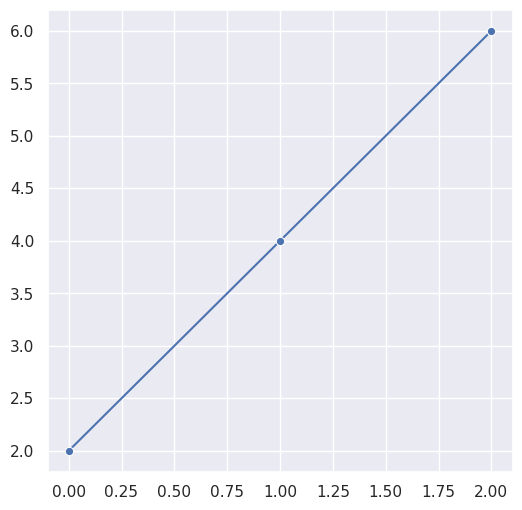

In [26]:
import seaborn as sns # le package doit avoir été installé au préalable

sns.set(rc={"figure.figsize": (6, 6)})
x=[0, 1, 2]
y=[2, 4, 6]
sns.lineplot(x=x, y=y, marker="o")